## Importing the necessary modules to form the rail form rolland

In [8]:
from rolland import DiscrPad, Sleeper, Ballast
from rolland.database.rail.db_rail import UIC60
from rolland import SimplePeriodicBallastedSingleRailTrack
from rolland import (
      PMLRailDampVertic,
      GaussianImpulse,
      DiscretizationEBBVerticConst,
      DeflectionEBBVertic)
from rolland.postprocessing import Response as resp
import numpy as np
import scipy as sp
from rolland import track
from frequency_domain import monopole_multi_fa__calcf__outf
from provided_data.plot_discplacement import npy_files
from rail_deflection import rail_deflection_rolland
from time_domain import monopole_multi_ta__calct__outf
from utils import interpolate_contour_2d, create_mesh, calculate_centre_and_area_triangles, calculate_projected_area, \
    assign_v_to_points, semi_circle_measurement_points, vector_deflection_total
from matplotlib import pyplot as plt

## Creating a track
In order to create a track we are going to input the variables such as:
- `rail`: the type of rail we want to use, in this case we are going to use the `UIC60` rail.
- `sleeper`: the type of sleeper we want to use, in this case we are going to use the `Sleeper` class with the following parameters: `mass=150`,
- `ballast`: the type of ballast we want to use, in this case we are going to use the `Ballast` class with the following parameters: `stiffness=105e6`, `damping=75000`.
- the `Pad` class with the following parameters: `stiffness=4.5e8`, `damping=33000`.

In [9]:
track = SimplePeriodicBallastedSingleRailTrack(
    rail=UIC60,  # Standard UIC60 rail profile
    pad=DiscrPad(
        sp=[4.5e8, 0],  # Stiffness properties [N/m]
        dp=[33000, 0]  # Damping properties [Ns/m]
    ),
    sleeper=Sleeper(ms=150),  # Sleeper mass [kg]
    ballast=Ballast(
        sb=[105e6, 0],  # Ballast stiffness [N/m]
        db=[75000, 0]  # Ballast damping [Ns/m]
    ),
    num_mount=243,  # Number of discrete mounting positions
    distance=0.6  # Distance between sleepers [m]
)

## Seeting up the perfectly mathched layer boundry
This will ensure that the waves generated by the sources will not be reflected back into the domain, which would affect the results of the simulation.
This simulates an endless track, which is a common assumption in railway dynamics to avoid boundary effects.
To achive this the damping properties of the PML are set to be very high, which will absorb the waves as they reach the boundary, preventing reflections and simulating an infinite track. The `l_bound` parameter defines the length of the boundary domain, which is set to 33.0 meters in this case.

In [10]:
boundary = PMLRailDampVertic(l_bound=33.0)  # 33.0 m boundary domain

## Setting up the gaussian impulse source
The `GaussianImpulse` class is used to create a source that generates a Gaussian-shaped impulse in

In [11]:
# Define excitation (Gaussian impulse between sleepers at 71.7m)
excitation = GaussianImpulse(x_excit=71.7)

## Getting the response

In [12]:
resp_func, dict_func = rail_deflection_rolland(track, boundary, excitation)

## Creating a 3D rail model by extruding a mesh of the rail profile
In order to create the 3D rail model, we first need to create a mesh of the rail profile. This is done by using the `create_mesh` function, which takes in the coordinates of the rail profile and the number of points to be used in the mesh. The `calculate_centre_and_area_triangles` function is then used to calculate the center and area of each triangle in the mesh, which is necessary for the finite element analysis. Finally, the `calculate_projected_area` function is used to calculate the projected area of each triangle on the horizontal plane, which is also necessary for the finite element analysis.

In [14]:
rail_geometry = UIC60.rl_geo
rail_geometry = interpolate_contour_2d(rail_geometry, 100)
triangle_coords, triangle_index = create_mesh(rail_geometry,
                                              mesh_size=10.0,
                                              L=146.0 #146.0
                                              )

A, centre, norm = calculate_centre_and_area_triangles(triangle_coords, triangle_index)
print(f'mean area = {A.mean()}')
projected_area = calculate_projected_area(A, norm, 1)


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 10%] Meshing curve 7 (Line)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 10%] Meshing curve 9 (Line)
Info    : [ 10%] Meshing curve 10 (Line)
Info    : [ 10%] Meshing curve 11 (Line)
Info    : [ 10%] Meshing curve 12 (Line)
Info    : [ 10%] Meshing curve 13 (Line)
Info    : [ 10%] Meshing curve 14 (Line)
Info    : [ 10%] Meshing curve 15 (Line)
Info    : [ 10%] Meshing curve 16 (Line)
Info    : [ 10%] Meshing curve 17 (Line)
Info    : [ 10%] Meshing curve 18 (Line)
Info    : [ 10%] Meshing curve 19 (Line)
Info    : [ 10%] Meshing curve 20 (Line)
Info    : [ 10%] Meshing curve 21 (Line)
Info    : [ 10%] Meshing curve 22 (Line)
Info    : [ 10%] Meshing curve 23 (Line)
Info    : [ 10%] Meshing curve 24 (Line)
I

## Simulating:

now we have the response from the rolland model.
We can now use this response to simulate the noise generated by the rail using the `monopole_multi_fa__calcf__outf` function.
`rail_v_fd` is the velocity of the rail in the frequency domain, which is obtained by taking the Fourier transform of the deflection and multiplying it by `1j * omega`.

In [15]:
print(f'projected_area mean = {projected_area.mean()}')
nt = dict_func['nt']
dt = dict_func['dt']
deflection = dict_func['deflection'][0::2, :nt]
full_freq_spectrum = sp.fft.fftfreq(nt, dt)

f_axis_sim = dict_func['frequencies']
mask = (full_freq_spectrum > f_axis_sim[0]) & (full_freq_spectrum < f_axis_sim[-1])

deflection_fd = sp.fft.fft(deflection, norm='forward', axis=1) * 2

omega = 2 * np.pi * f_axis_sim

rail_v_fd = (1j * omega[None, :]) * deflection_fd
rail_v_td = np.gradient(deflection, dt, axis=1)


nx = dict_func['nx']
dx = dict_func['dx']
x_axis = np.arange(nx) * dx
L = nx * dx
print(L)

projected_area mean = 0.015866568052804283
145.25454545454545


In [16]:
triangle_v_fd = assign_v_to_points(
    x_axis,
    rail_v_fd,
    centre
)

triangle_v_td = assign_v_to_points(
    x_axis,
    rail_v_td,
    centre
)

print(triangle_v_fd.shape)

(3816, 20000)


## Simulating it in a given mesh
For examply just one semiciurle of measurement points around the source, to see how the results look like.

In [18]:

P_all = []
P_all_td = []
z_axis_points = np.linspace(71.7, 71.7, 1)
for point_z in z_axis_points:
    measurement_points = semi_circle_measurement_points(
        np.array((-0.71, -0.8, point_z)),
        10,
        2.5
    )
    for point in measurement_points:
        P = monopole_multi_fa__calcf__outf(triangle_v_fd,
                                           f_axis_sim,
                                           centre,
                                           point,
                                           projected_area[:, None],)
        p_fd_from_ta = monopole_multi_ta__calct__outf(
                                            triangle_v_td,
                                            centre,
                                            point,
                                            dt,
                                            projected_area[:, None],
                                        ) * 2 #multiplied by 2 because inside fft with no correction
        P_all.append(np.abs(P) ** 2 )
        P_all_td.append(np.abs(p_fd_from_ta) ** 2)


P_mean = np.mean(P_all, axis=0)
P_mean_td = np.mean(P_all_td, axis=0)

## Plotting the results

- First we add the resutls of Wagner that used the same model to generate verticle vibrations

- And then we are adding the results of the monopole model with the same verticle vibrations but using the monopole model to generate the noise, to see how they compare.

(852, 2)
[ 100.18466273  100.80370683  100.80447916  101.42657602  101.42735312
  102.05329394  102.05407584  102.68388436  102.6846711   103.31863509
  103.16017329  103.9573096   104.599665    105.24598953  105.89630772
  106.55064424  106.88014602  107.20902394  107.54056171  107.87147178
  108.20505813  108.5380129   108.8736605   109.2086726   109.54625429
  110.2230032   110.90407451  111.58935418  112.27886822  112.97264278
  113.32200422  113.6707042   114.02222435  114.37307896  114.72677117
  115.07979371  115.4356714   115.79087528  116.14880363  116.86634141
  117.58846211  118.31504481  119.04611709  119.7817067   120.15212477
  120.52184153  120.89454843  121.26654967  121.64155955  122.0158594
  122.39318646  122.76979913  123.14930045  123.91008552  124.67572973
  125.44610488  126.22124021  127.00116511  127.39390895  127.7859092
  128.18107981  128.57550224  128.97311463  129.36997421  129.77004345
  130.16935524  130.57172979  131.37836874  132.1901597   133.00696674

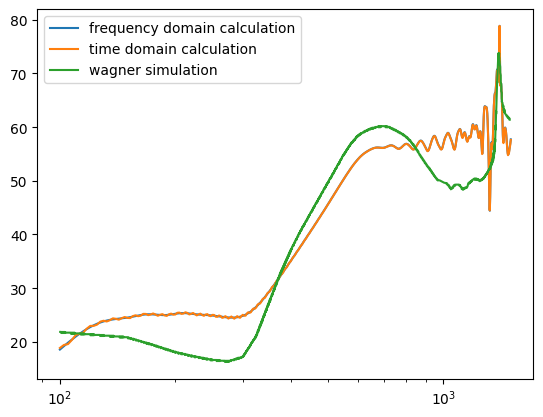

In [19]:
P_mean = np.mean(P_all, axis=0)
P_mean_td = np.mean(P_all_td, axis=0)
with open("Default Dataset.csv", "r") as f:
    content = f.read().replace(",", ".")
with open("Default Dataset.csv", "w") as f:
    f.write(content)
wagner_simulation_data = np.genfromtxt('Default Dataset.csv', delimiter=';')
print(wagner_simulation_data.shape)
print(wagner_simulation_data[:, 0])
print(wagner_simulation_data[:, 1])

p0 = 2e-5
P_db = 20 * np.log10((np.sqrt(P_mean) + p0)/ p0)
P_td_db = 20 * np.log10((np.sqrt(P_mean_td) +p0)/ p0)
plt_mask = (f_axis_sim >= 100) & (f_axis_sim <= 1500)
plt_f_axis = f_axis_sim[plt_mask]
plt_P_db = P_db[plt_mask]
plt_P_td_db = P_td_db[plt_mask]
#plt.plot(f_axis_sim[:len(f_axis_sim)//2], P_db)
plt.plot(plt_f_axis, plt_P_db, label="frequency domain calculation")
plt.plot(plt_f_axis, plt_P_td_db, label="time domain calculation")
plt.plot(wagner_simulation_data[:, 0], wagner_simulation_data[:, 1], label="wagner simulation")
plt.legend()
plt.xscale('log')
plt.show()

## New simulation with more degree of freedom

A new more advanced simulation results are provided.
In the new simulation results, there are rail displacements in the
- vertical direction
- lateral direction
- and also the rotation of the rail around the vertical axis

This allows for a more accurate simulation of the noise generated by the rail.

In [24]:
u_y_pos_1 = np.load('provided_data/u_y_exc_at_pos1.npy')
u_y_pos_2 = np.load('provided_data/u_y_exc_at_pos2.npy')
u_z_pos_1 = np.load('provided_data/u_z_exc_at_pos1.npy')
u_z_pos_2 = np.load('provided_data/u_z_exc_at_pos2.npy')
phi_x_pos1 = np.load('provided_data/phi_x_exc_at_pos1.npy')
phi_x_pos2 = np.load('provided_data/phi_x_exc_at_pos2.npy')

In [25]:
u_x = u_y_pos_1 + u_y_pos_2
u_y = u_z_pos_1 + u_z_pos_2
phi_z = phi_x_pos1 + phi_x_pos2

In [27]:
from utils import vector_deflection_total
triangle_v_x, triangle_v_y = vector_deflection_total(
    u_x,
    u_y,
    phi_z,
    centre,
)



## Simulating the noise generated

### Simulation of the noise generated by the verticle component of the vibrarions, using the monopole model.

In [29]:
print(f'shape of triangle_v_y = {triangle_v_y.shape} '
      f'shape of triangle_v_x = {triangle_v_x.shape}'
      f'shape of f_axis_sim = {f_axis_sim.shape}'
      f'shape of projected area = {projected_area.shape}')

shape of triangle_v_y = (99999, 3816) shape of triangle_v_x = (99999, 3816)shape of f_axis_sim = (20000,)shape of projected area = (3816,)


In [50]:
triangle_v_y_fd = sp.fft.fft(triangle_v_y, norm='forward', axis=1) * 2
f_axis_sim = sp.fft.fftfreq(triangle_v_y.shape[1], 0.5e-5)
omega = 2 * np.pi * f_axis_sim

triangle_v_y_fd = (1j * omega[None, :]) * triangle_v_y_fd.T


p_fd_from_fd_new = monopole_multi_fa__calcf__outf(
    triangle_v_y_fd,
    f_axis_sim,
    centre,
    np.array((2.5, -0.8, 32.5)),
    projected_area[:, None],
)

ValueError: operands could not be broadcast together with shapes (1,3816) (3816,99999) 

## Plot the noise generated by the verticle component of the vibrations, using the monopole model.

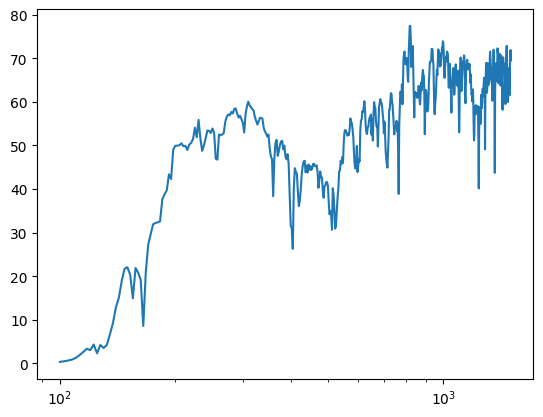

In [48]:
p0 = 2e-5
P_db = 20 * np.log10((np.abs(p_fd_from_fd_new) + p0) / p0)
plt_mask = (f_axis_sim >= 100) & (f_axis_sim <= 1500)
plt_f_axis = f_axis_sim[plt_mask]
plt_P_db = P_db[plt_mask]
plt.plot(plt_f_axis, plt_P_db)
plt.xscale('log')

## Simulation of the noise generated by the lateral component of the vibrarions, using the monopole model.

In [44]:
triangle_v_x_fd = sp.fft.fft(triangle_v_x, norm='forward', axis=1) * 2
omega = 2 * np.pi * f_axis_sim

triangle_v_x_fd = (1j * omega[None, :]) * triangle_v_x_fd[:20000].T

projected_area = calculate_projected_area(A, norm, 0)


p_fd_from_fd_new_2 = monopole_multi_fa__calcf__outf(
    triangle_v_x_fd,
    f_axis_sim,
    centre,
    np.array((2.5, -0.8, 32.5)),
    projected_area[:, None],
)

## Plotting the noise form the lateral component

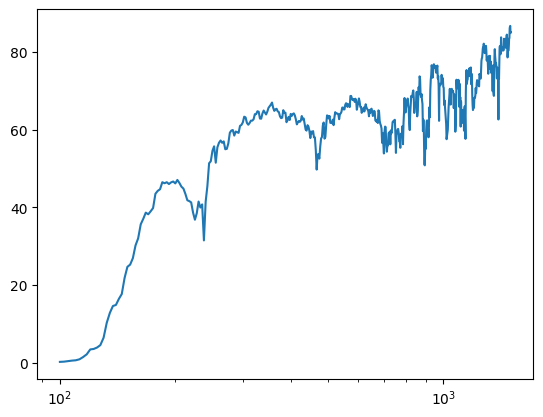

In [49]:
p0 = 2e-5
P_db = 20 * np.log10((np.abs(p_fd_from_fd_new_2) + p0) / p0)
plt_mask = (f_axis_sim >= 100) & (f_axis_sim <= 1500)
plt_f_axis = f_axis_sim[plt_mask]
plt_P_db = P_db[plt_mask]
plt.plot(plt_f_axis, plt_P_db)
plt.xscale('log')